# Steam 遊戲成功因素分析：價格、Tag 與發行時間如何影響好評率與市場熱度？

本專案分析 2025 年 3 月的 Steam 遊戲資料，目標是找出哪些產品特徵與市場因素，較容易和高好評率及高市場熱度相關。

本分析將「成功遊戲」定義為同時符合：

- 總好評率 `pct_pos_total >= 80`
- 總評論數 `num_reviews_total >= 1000`

這樣可以避免只用好評率判斷時，少量評論遊戲造成的偏誤。

主要研究問題：

1. 哪些價格區間的遊戲成功率較高？
2. 免費遊戲與付費遊戲的口碑表現是否不同？
3. 哪些 Tag 更常與成功遊戲相關？
4. 獨立遊戲要在 Steam 市場存活，需要哪些特徵？
5. 是否能用產品層級特徵預測遊戲成功機率？

## 1. Project Background

Steam 平台遊戲數量龐大，單純上架並不代表能獲得玩家關注。本專案從價格、Tag、發行時間、獨立遊戲與機器學習模型五個角度，分析哪些因素與遊戲成功較相關。

## 2. Data Loading and Overview

先讀取資料，確認資料筆數、欄位型態、缺失值與基本統計。

In [1]:
import ast
from collections import Counter
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

sns.set_theme(style="whitegrid")

candidate_paths = [
    Path("games_march2025_cleaned.csv"),
    Path("../work/data/raw/games_march2025_cleaned.csv"),
    Path("../work/games_march2025_cleaned.csv"),
    Path(r"D:\下載\games_march2025_cleaned.csv"),
]

DATA_PATH = next((path for path in candidate_paths if path.exists()), None)

if DATA_PATH is None:
    raise FileNotFoundError("Could not find games_march2025_cleaned.csv. Please place it in the same folder as this notebook.")

df = pd.read_csv(DATA_PATH)
df.head()

,appid,name,release_date,required_age,price,dlc_count,detailed_description,about_the_game,short_description,reviews,...,average_playtime_2weeks,median_playtime_forever,median_playtime_2weeks,discount,peak_ccu,tags,pct_pos_total,num_reviews_total,pct_pos_recent,num_reviews_recent
0,730,Counter-Strike 2,2012-08-21,0,0.00,1,"For over two decades, Counter-Strike has offer...","For over two decades, Counter-Strike has offer...","For over two decades, Counter-Strike has offer...",NaN,...,879,5174,350,0,1212356,"{'FPS': 90857, 'Shooter': 65397, 'Multiplayer'...",86,8632939,82,96473
1,578080,PUBG: BATTLEGROUNDS,2017-12-21,0,0.00,0,"LAND, LOOT, SURVIVE! Play PUBG: BATTLEGROUNDS ...","LAND, LOOT, SURVIVE! Play PUBG: BATTLEGROUNDS ...",Play PUBG: BATTLEGROUNDS for free. Land on str...,NaN,...,0,0,0,0,616738,"{'Survival': 14838, 'Shooter': 12727, 'Battle ...",59,2513842,68,16720
2,570,Dota 2,2013-07-09,0,0.00,2,"The most-played game on Steam. Every day, mill...","The most-played game on Steam. Every day, mill...","Every day, millions of players worldwide enter...",“A modern multiplayer masterpiece.” 9.5/10 – D...,...,1536,898,892,0,555977,"{'Free to Play': 59933, 'MOBA': 20158, 'Multip...",81,2452595,80,29366
3,271590,Grand Theft Auto V Legacy,2015-04-13,17,0.00,0,"When a young street hustler, a retired bank ro...","When a young street hustler, a retired bank ro...",Grand Theft Auto V for PC offers players the o...,NaN,...,771,7101,74,0,117698,"{'Open World': 32644, 'Action': 23539, 'Multip...",87,1803832,92,17517
4,359550,Tom Clancy's Rainbow Six® Siege,2015-12-01,17,3.99,9,Edition Comparison Ultimate Edition The Tom Cl...,“One of the best first-person shooters ever ma...,"Tom Clancy's Rainbow Six® Siege is an elite, t...",NaN,...,682,2434,306,80,89916,"{'FPS': 9831, 'PvP': 9162, 'e-sports': 9072, '...",84,1168020,76,12608


In [2]:
df.shape

(89618, 47)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 89618 entries, 0 to 89617
Data columns (total 47 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   appid                     89618 non-null  int64  
 1   name                      89618 non-null  object 
 2   release_date              89618 non-null  object 
 3   required_age              89618 non-null  int64  
 4   price                     89618 non-null  float64
 5   dlc_count                 89618 non-null  int64  
 6   detailed_description      89421 non-null  object 
 7   about_the_game            89398 non-null  object 
 8   short_description         89498 non-null  object 
 9   reviews                   10401 non-null  object 
 10  header_image              89618 non-null  object 
 11  website                   41114 non-null  object 
 12  support_url               44110 non-null  object 
 13  support_email             78798 non-null  object 
 14  window

In [4]:
df.describe()

,appid,required_age,price,dlc_count,metacritic_score,achievements,recommendations,user_score,score_rank,positive,...,average_playtime_forever,average_playtime_2weeks,median_playtime_forever,median_playtime_2weeks,discount,peak_ccu,pct_pos_total,num_reviews_total,pct_pos_recent,num_reviews_recent
count,8.961800e+04,89618.000000,89618.000000,89618.000000,89618.000000,89618.000000,8.961800e+04,89618.000000,39.000000,8.961800e+04,...,8.961800e+04,89618.000000,8.961800e+04,89618.000000,89618.000000,8.961800e+04,89618.000000,8.961800e+04,89618.000000,89618.000000
mean,1.656904e+06,0.183624,7.309623,0.595583,2.903245,20.552333,1.009401e+03,0.032817,99.128205,1.269896e+03,...,1.149119e+02,5.032694,1.147559e+02,5.301814,4.558627,9.833994e+01,45.352418,1.315490e+03,5.231639,15.584581
std,9.168390e+05,1.725594,13.331073,15.351920,14.445358,163.562418,2.204815e+04,1.615149,0.695076,3.181441e+04,...,6.814748e+03,181.100334,8.806711e+03,189.591095,16.538036,5.717544e+03,40.685695,3.542370e+04,22.335358,444.277307
min,2.000000e+01,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,98.000000,0.000000e+00,...,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000,0.000000e+00,-1.000000,-1.000000e+00,-1.000000,-1.000000
25%,8.550525e+05,0.000000,0.990000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,99.000000,1.000000e+00,...,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000,0.000000e+00,-1.000000,-1.000000e+00,-1.000000,-1.000000
50%,1.524730e+06,0.000000,4.990000,0.000000,0.000000,5.000000,0.000000e+00,0.000000,99.000000,1.000000e+01,...,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000,0.000000e+00,60.000000,1.500000e+01,-1.000000,-1.000000
75%,2.430852e+06,0.000000,9.990000,0.000000,0.000000,20.000000,0.000000e+00,0.000000,100.000000,5.800000e+01,...,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000,0.000000e+00,84.000000,8.100000e+01,-1.000000,-1.000000
max,3.542350e+06,21.000000,999.980000,3427.000000,97.000000,9821.000000,4.401572e+06,100.000000,100.000000,7.480813e+06,...,1.462997e+06,18568.000000,1.462997e+06,18568.000000,100.000000,1.212356e+06,100.000000,8.632939e+06,100.000000,96473.000000


In [5]:
df.isnull().sum().sort_values(ascending=False).head(20)

score_rank                  89579
metacritic_url              86071
reviews                     79217
notes                       72975
website                     48504
support_url                 45508
support_email               10820
about_the_game                220
detailed_description          197
short_description             120
estimated_owners                0
appid                           0
negative                        0
positive                        0
user_score                      0
movies                          0
average_playtime_forever        0
discount                        0
average_playtime_2weeks         0
median_playtime_forever         0
dtype: int64

資料集共有 89,618 筆遊戲與 47 個欄位。核心數值欄位如價格、評論數、好評率、遊玩時間與同時在線峰值大多完整；部分文字或外部連結欄位缺失較多，因此本專案不以這些欄位作為主要分析對象。

## 3. Data Cleaning and Feature Engineering

建立後續分析會使用的欄位，包括發行年份、發行月份、是否免費、價格區間，以及清理評論相關欄位中的 `-1` 值。

In [6]:
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['release_year'] = df['release_date'].dt.year
df['release_month'] = df['release_date'].dt.month

df['is_free'] = df['price'] == 0

df['pct_pos_total_clean'] = df['pct_pos_total'].mask(df['pct_pos_total'] == -1)
df['num_reviews_total_clean'] = df['num_reviews_total'].mask(df['num_reviews_total'] == -1)

df['price_group'] = pd.cut(
    df['price'],
    bins=[-1, 0, 5, 10, 20, 40, 1000],
    labels=['Free', '0-5', '5-10', '10-20', '20-40', '40+']
)

df[['release_date', 'release_year', 'release_month', 'is_free', 'price_group']].head()

,release_date,release_year,release_month,is_free,price_group
0,2012-08-21,2012,8,True,Free
1,2017-12-21,2017,12,True,Free
2,2013-07-09,2013,7,True,Free
3,2015-04-13,2015,4,True,Free
4,2015-12-01,2015,12,False,0-5


## 4. Success Definition

定義成功遊戲，並檢查成功遊戲比例與代表性遊戲。

In [7]:
df['is_successful'] = (
    (df['pct_pos_total'] >= 80) &
    (df['num_reviews_total'] >= 1000)
)

In [8]:
df['is_successful'].value_counts()

is_successful
False    85187
True      4431
Name: count, dtype: int64

In [9]:
df['is_successful'].value_counts(normalize=True)

is_successful
False    0.950557
True     0.049443
Name: proportion, dtype: float64

In [10]:
df[df['is_successful']][
    ['name', 'release_date', 'price', 'pct_pos_total', 'num_reviews_total', 'peak_ccu']
].sort_values('num_reviews_total', ascending=False).head(20)

,name,release_date,price,pct_pos_total,num_reviews_total,peak_ccu
0,Counter-Strike 2,2012-08-21,0.00,86,8632939,1212356
2,Dota 2,2013-07-09,0.00,81,2452595,555977
3,Grand Theft Auto V Legacy,2015-04-13,0.00,87,1803832,117698
4,Tom Clancy's Rainbow Six® Siege,2015-12-01,3.99,84,1168020,89916
5,Team Fortress 2,2007-10-10,0.00,89,1146642,50817
6,Terraria,2011-05-16,9.99,97,1102434,30516
7,Rust,2018-02-08,39.99,87,993856,200902
8,Garry's Mod,2006-11-29,5.99,96,985010,32384
10,Black Myth: Wukong,2024-08-19,59.99,96,825621,35990
11,The Witcher 3: Wild Hunt,2015-05-18,39.99,96,751939,15129


在此定義下，共有 4,431 款遊戲被歸類為成功遊戲，占整體約 4.94%。這代表能同時達到高好評率與足夠評論數的遊戲其實相當少。

## 5. Pricing Analysis

比較不同價格區間的成功率、好評率與評論數。

In [11]:
price_success = df.groupby('price_group', observed=False).agg(
    game_count=('appid', 'count'),
    successful_rate=('is_successful', 'mean'),
    median_positive_rate=('pct_pos_total_clean', 'median'),
    median_reviews=('num_reviews_total_clean', 'median')
).reset_index()

price_success

,price_group,game_count,successful_rate,median_positive_rate,median_reviews
0,Free,14160,0.054732,80.0,54.0
1,0-5,39456,0.016651,80.0,34.0
2,5-10,19045,0.037228,82.0,50.0
3,10-20,12723,0.110666,82.0,129.0
4,20-40,3342,0.214542,81.0,483.0
5,40+,892,0.184978,80.0,1241.0


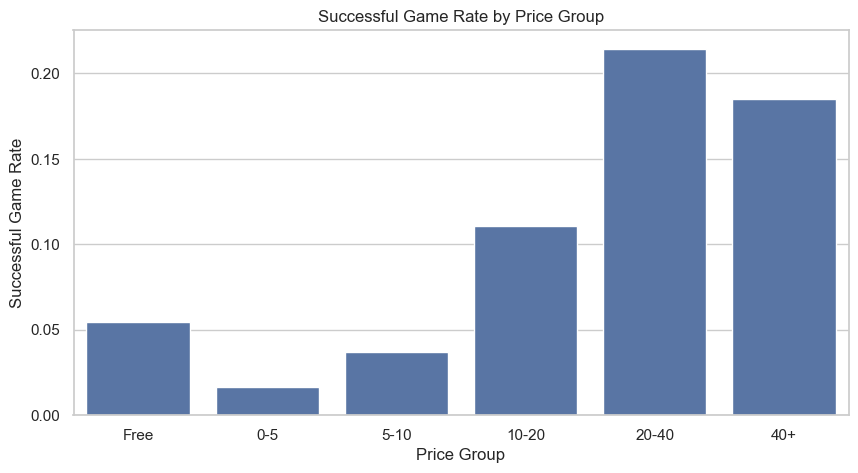

In [12]:
plt.figure(figsize=(10, 5))
sns.barplot(data=price_success, x='price_group', y='successful_rate')
plt.title('Successful Game Rate by Price Group')
plt.xlabel('Price Group')
plt.ylabel('Successful Game Rate')
plt.show()

20-40 美元區間的成功率最高，其次是 40 美元以上區間。這表示成功遊戲通常能支撐中高價位，但這是相關性而非因果關係；高價可能同時反映較高製作規模、品牌知名度或內容量。

## 6. Free vs Paid Game Analysis

先比較全部遊戲，再過濾掉評論數過少的遊戲，避免小樣本好評率造成偏誤。

In [13]:
df.groupby('is_free').agg(
    game_count=('appid', 'count'),
    successful_rate=('is_successful', 'mean'),
    median_positive_rate=('pct_pos_total_clean', 'median'),
    median_reviews=('num_reviews_total_clean', 'median'),
    median_peak_ccu=('peak_ccu', 'median')
)

,game_count,successful_rate,median_positive_rate,median_reviews,median_peak_ccu
is_free,,,,,
False,75458,0.048451,81.0,55.0,0.0
True,14160,0.054732,80.0,54.0,0.0


In [14]:
df_reviewed = df[df['num_reviews_total'] >= 100]

In [15]:
df_reviewed.groupby('is_free').agg(
    game_count=('appid', 'count'),
    successful_rate=('is_successful', 'mean'),
    median_positive_rate=('pct_pos_total_clean', 'median'),
    median_reviews=('num_reviews_total_clean', 'median'),
    median_peak_ccu=('peak_ccu', 'median')
)

,game_count,successful_rate,median_positive_rate,median_reviews,median_peak_ccu
is_free,,,,,
False,16115,0.226869,84.0,404.0,2.0
True,4268,0.181584,82.0,378.5,0.0


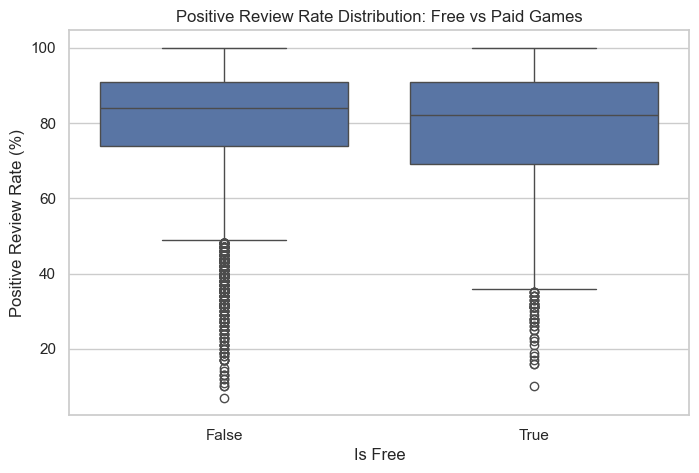

In [16]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_reviewed, x='is_free', y='pct_pos_total')
plt.title('Positive Review Rate Distribution: Free vs Paid Games')
plt.xlabel('Is Free')
plt.ylabel('Positive Review Rate (%)')
plt.show()

在完整資料中，免費遊戲看起來有較高好評率與評論數中位數。然而，過濾至至少 100 則評論後，付費遊戲的成功率與好評率中位數略高，表示大量低評論數遊戲會影響定價策略分析。

## 7. Tag Analysis

解析 Steam Tag，先看成功遊戲最常出現的 Tag，再計算各 Tag 的成功率。

In [17]:
def parse_tags(x):
    try:
        tag_dict = ast.literal_eval(x)
        return list(tag_dict.keys())
    except:
        return []

df['tag_list'] = df['tags'].apply(parse_tags)
df[['name', 'tag_list']].head()

,name,tag_list
0,Counter-Strike 2,"[FPS, Shooter, Multiplayer, Competitive, Actio..."
1,PUBG: BATTLEGROUNDS,"[Survival, Shooter, Battle Royale, Multiplayer..."
2,Dota 2,"[Free to Play, MOBA, Multiplayer, Strategy, e-..."
3,Grand Theft Auto V Legacy,"[Open World, Action, Multiplayer, Crime, Autom..."
4,Tom Clancy's Rainbow Six® Siege,"[FPS, PvP, e-sports, Multiplayer, Tactical, Sh..."


In [18]:
success_tags = Counter(
    tag
    for tags in df[df['is_successful']]['tag_list']
    for tag in tags
)

success_tags.most_common(30)

[('Singleplayer', 3281),
 ('Adventure', 2190),
 ('Indie', 2183),
 ('Action', 2107),
 ('Atmospheric', 1444),
 ('Story Rich', 1423),
 ('Multiplayer', 1381),
 ('2D', 1353),
 ('Casual', 1344),
 ('Simulation', 1181),
 ('RPG', 1151),
 ('Great Soundtrack', 1139),
 ('Strategy', 1064),
 ('Funny', 958),
 ('First-Person', 862),
 ('Exploration', 851),
 ('Puzzle', 843),
 ('Co-op', 840),
 ('Open World', 813),
 ('Cute', 789),
 ('Anime', 746),
 ('Horror', 733),
 ('Fantasy', 726),
 ('Pixel Graphics', 715),
 ('Difficult', 710),
 ('Female Protagonist', 663),
 ('Shooter', 637),
 ('Sandbox', 632),
 ('3D', 611),
 ('Sci-fi', 587)]

In [19]:
tag_rows = []

for _, row in df.iterrows():
    for tag in row['tag_list']:
        tag_rows.append({
            'tag': tag,
            'is_successful': row['is_successful'],
            'pct_pos_total': row['pct_pos_total'],
            'num_reviews_total': row['num_reviews_total'],
            'price': row['price']
        })

tag_df = pd.DataFrame(tag_rows)

In [20]:
tag_summary = tag_df.groupby('tag').agg(
    game_count=('is_successful', 'size'),
    successful_rate=('is_successful', 'mean'),
    median_positive_rate=('pct_pos_total', 'median'),
    median_reviews=('num_reviews_total', 'median'),
    median_price=('price', 'median')
).reset_index()

tag_summary_filtered = tag_summary[tag_summary['game_count'] >= 200]
tag_summary_filtered.sort_values('successful_rate', ascending=False).head(30)

,tag,game_count,successful_rate,median_positive_rate,median_reviews,median_price
103,Cult Classic,258,0.329457,87.0,508.0,9.99
247,Moddable,791,0.293300,81.0,328.0,12.99
177,Great Soundtrack,3897,0.292276,84.0,332.0,9.99
320,Remake,383,0.281984,81.0,269.0,11.99
79,Classic,1145,0.254148,84.0,295.0,6.99
270,Nostalgia,204,0.235294,87.0,136.0,6.99
316,Real-Time with Pause,285,0.207018,75.0,228.0,9.99
235,Mature,1332,0.194444,79.0,194.0,5.99
404,Touch-Friendly,233,0.188841,86.0,157.0,4.99
81,Co-op,4584,0.183246,73.0,97.0,8.99


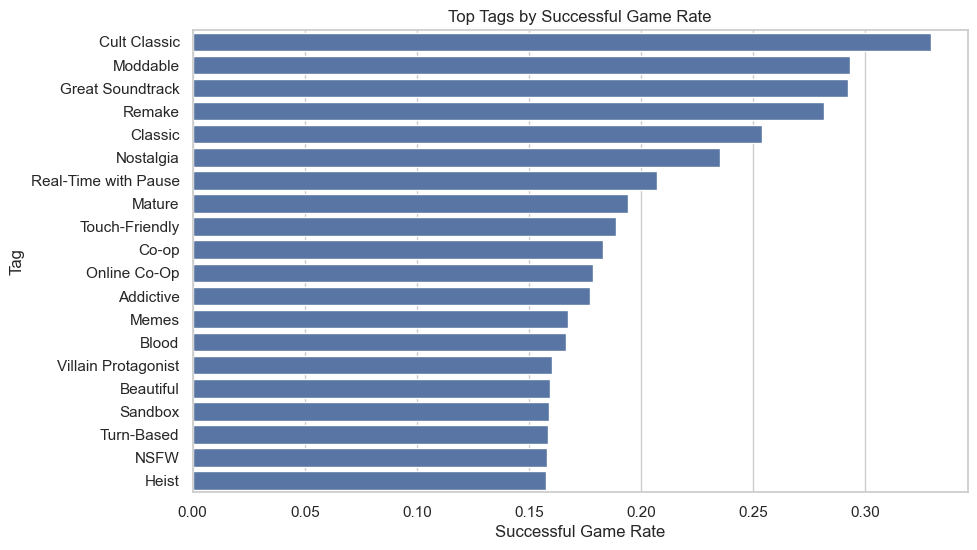

In [21]:
top_tags = tag_summary_filtered.sort_values('successful_rate', ascending=False).head(20)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_tags, x='successful_rate', y='tag')
plt.title('Top Tags by Successful Game Rate')
plt.xlabel('Successful Game Rate')
plt.ylabel('Tag')
plt.show()

成功遊戲最常見的 Tag 包含 Singleplayer、Adventure、Indie、Action 等大型類別，但成功率最高的 Tag 更集中在 Cult Classic、Moddable、Great Soundtrack、Remake、Classic、Nostalgia 等。這表示長期社群價值、可重玩性與情感連結，比單純選擇熱門類型更能解釋成功率差異。

## 8. Release Timing Analysis

分析發行年份與月份是否和成功率相關。2025 年資料只到 3 月，因此不能和完整年度直接比較。

In [22]:
year_summary_clean = df.groupby('release_year').agg(
    game_count=('appid', 'count'),
    successful_rate=('is_successful', 'mean'),
    median_positive_rate=('pct_pos_total_clean', 'median'),
    median_reviews=('num_reviews_total_clean', 'median')
).reset_index()

year_summary_clean.tail(15)

,release_year,game_count,successful_rate,median_positive_rate,median_reviews
12,2011,212,0.273585,80.0,527.5
13,2012,309,0.284790,82.0,663.0
14,2013,460,0.326087,81.0,793.0
15,2014,1525,0.142295,76.0,200.0
16,2015,2521,0.102340,75.0,121.0
17,2016,4160,0.078125,76.0,89.0
18,2017,5967,0.051617,76.0,62.0
19,2018,7443,0.046890,76.0,47.0
20,2019,6146,0.056134,79.0,59.0
21,2020,8568,0.052638,81.0,49.0


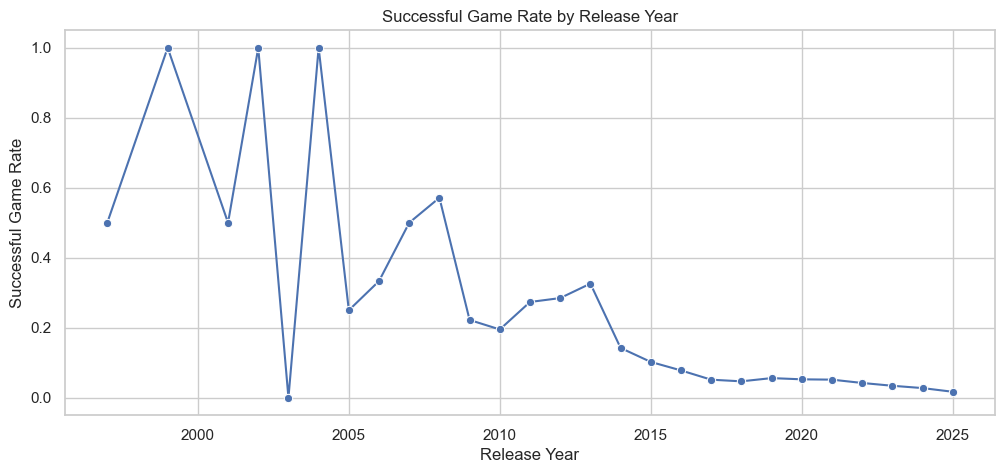

In [23]:
plt.figure(figsize=(12, 5))
sns.lineplot(data=year_summary_clean, x='release_year', y='successful_rate', marker='o')
plt.title('Successful Game Rate by Release Year')
plt.xlabel('Release Year')
plt.ylabel('Successful Game Rate')
plt.show()

In [24]:
month_summary_clean = df.groupby('release_month').agg(
    game_count=('appid', 'count'),
    successful_rate=('is_successful', 'mean'),
    median_positive_rate=('pct_pos_total_clean', 'median'),
    median_reviews=('num_reviews_total_clean', 'median')
).reset_index()

month_summary_clean

,release_month,game_count,successful_rate,median_positive_rate,median_reviews
0,1,7280,0.043407,81.0,48.0
1,2,8083,0.041569,81.0,53.0
2,3,7624,0.048137,81.0,49.0
3,4,6927,0.052115,80.0,60.0
4,5,7402,0.052013,81.0,55.0
5,6,6497,0.047406,81.0,54.0
6,7,6882,0.046498,80.0,58.0
7,8,7231,0.058083,81.0,58.0
8,9,7360,0.058152,80.0,58.0
9,10,8620,0.054176,82.0,58.0


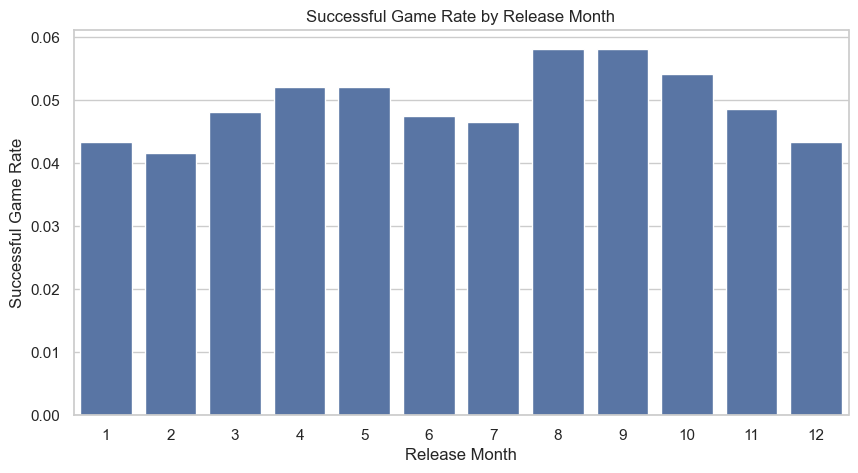

In [25]:
plt.figure(figsize=(10, 5))
sns.barplot(data=month_summary_clean, x='release_month', y='successful_rate')
plt.title('Successful Game Rate by Release Month')
plt.xlabel('Release Month')
plt.ylabel('Successful Game Rate')
plt.show()

隨著 Steam 發行數量快速增加，成功率呈下降趨勢。不過清理無效評論值後，近年遊戲的好評率中位數仍維持在高水準，表示成功率下降更可能與市場飽和、曝光競爭與評論累積困難有關，而不一定代表遊戲品質下降。月份差異則較小，8-10 月成功率略高，但不應視為主要決定因素。

## 9. Indie Game Survival Analysis

聚焦獨立遊戲，定義「存活」為至少 500 則評論且好評率至少 70%。

In [26]:
indie_games = df[df['genres'].str.contains('Indie', case=False, na=False)].copy()
indie_games.shape

(63189, 55)

In [27]:
indie_games['is_survived'] = (
    (indie_games['num_reviews_total'] >= 500) &
    (indie_games['pct_pos_total'] >= 70)
)

In [28]:
indie_games['is_survived'].value_counts()

is_survived
False    58148
True      5041
Name: count, dtype: int64

In [29]:
indie_games['is_survived'].value_counts(normalize=True)

is_survived
False    0.920223
True     0.079777
Name: proportion, dtype: float64

In [30]:
indie_games.groupby('is_survived').agg(
    game_count=('appid', 'count'),
    median_price=('price', 'median'),
    median_positive_rate=('pct_pos_total', 'median'),
    median_reviews=('num_reviews_total', 'median'),
    median_peak_ccu=('peak_ccu', 'median'),
    median_playtime=('average_playtime_forever', 'median')
)

,game_count,median_price,median_positive_rate,median_reviews,median_peak_ccu,median_playtime
is_survived,,,,,,
False,58148,3.99,53.0,13.0,0.0,0.0
True,5041,9.99,89.0,1592.0,7.0,0.0


In [31]:
indie_tag_rows = []

for _, row in indie_games.iterrows():
    for tag in row['tag_list']:
        indie_tag_rows.append({
            'tag': tag,
            'is_survived': row['is_survived'],
            'pct_pos_total': row['pct_pos_total'],
            'num_reviews_total': row['num_reviews_total'],
            'price': row['price']
        })

indie_tag_df = pd.DataFrame(indie_tag_rows)

In [32]:
indie_tag_summary = indie_tag_df.groupby('tag').agg(
    game_count=('is_survived', 'size'),
    survival_rate=('is_survived', 'mean'),
    median_positive_rate=('pct_pos_total', 'median'),
    median_reviews=('num_reviews_total', 'median'),
    median_price=('price', 'median')
).reset_index()

indie_tag_summary_filtered = indie_tag_summary[indie_tag_summary['game_count'] >= 200]
indie_tag_summary_filtered.sort_values('survival_rate', ascending=False).head(30)

,tag,game_count,survival_rate,median_positive_rate,median_reviews,median_price
246,Moddable,502,0.354582,81.5,196.5,11.990
177,Great Soundtrack,2713,0.327313,83.0,183.0,6.990
185,Hentai,643,0.267496,79.0,158.0,4.990
234,Mature,828,0.266908,77.0,141.0,4.990
260,NSFW,459,0.257081,78.0,127.0,4.990
276,Open World Survival Craft,422,0.255924,65.0,131.5,10.990
56,Boomer Shooter,204,0.245098,85.0,53.5,9.990
238,Memes,1152,0.243056,80.0,94.5,2.990
274,Online Co-Op,1795,0.235097,71.0,61.0,7.990
413,Turn-Based,1247,0.234162,77.0,114.0,9.990


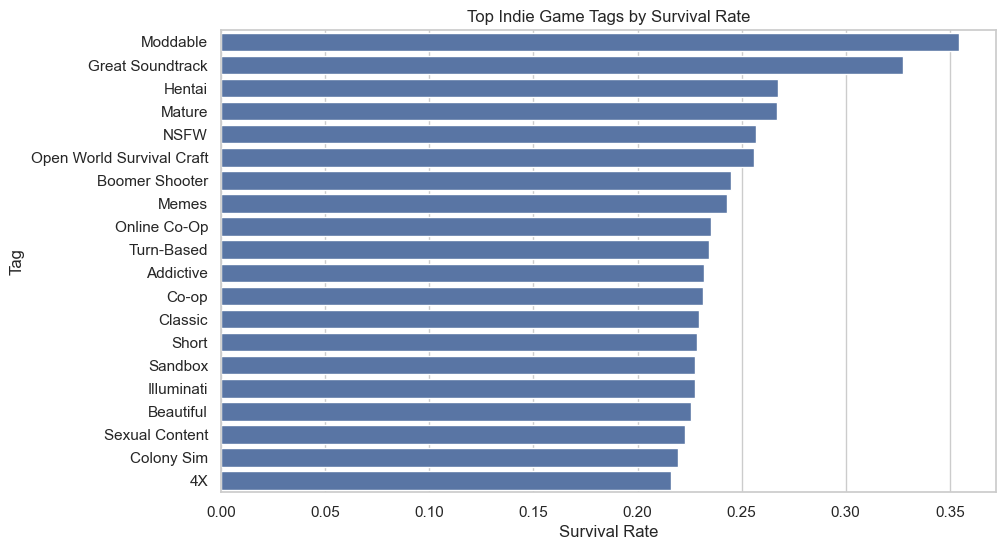

In [33]:
top_indie_tags = indie_tag_summary_filtered.sort_values(
    'survival_rate', ascending=False
).head(20)

plt.figure(figsize=(10, 6))
sns.barplot(data=top_indie_tags, x='survival_rate', y='tag')
plt.title('Top Indie Game Tags by Survival Rate')
plt.xlabel('Survival Rate')
plt.ylabel('Tag')
plt.show()

只有約 7.98% 的獨立遊戲達到存活門檻。存活獨立遊戲的中位價格、好評率、評論數與同時在線峰值都明顯較高。Moddable、Great Soundtrack、Co-op、Sandbox、Colony Sim、Roguelike Deckbuilder 等 Tag 的存活率較高，顯示可重玩性、社群延伸與明確利基定位對獨立遊戲很重要。

## 10. Machine Learning Model

建立兩版 Random Forest 分類模型。第一版包含發售後市場訊號，用於解釋成功特徵；第二版移除評論與玩家行為相關欄位，較接近產品層級預測。

### Model A: Market Performance Model

此模型包含 `recommendations` 與遊玩時間，因此適合解釋發售後成功訊號，不適合稱為純發售前預測。

In [34]:
features = [
    'price',
    'required_age',
    'dlc_count',
    'achievements',
    'recommendations',
    'average_playtime_forever',
    'median_playtime_forever',
    'discount',
    'release_year',
    'is_free'
]

model_df = df[features + ['is_successful']].dropna()

X = model_df[features]
y = model_df['is_successful']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced',
    max_depth=8
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

       False       1.00      0.96      0.98     17038
        True       0.53      0.93      0.68       886

    accuracy                           0.96     17924
   macro avg       0.76      0.94      0.83     17924
weighted avg       0.97      0.96      0.96     17924

[[16313   725]
 [   64   822]]
ROC AUC: 0.9859065859159066


In [35]:
feature_importance = pd.DataFrame({
    'feature': features,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

feature_importance

,feature,importance
4,recommendations,0.552274
6,median_playtime_forever,0.102653
5,average_playtime_forever,0.092420
2,dlc_count,0.070991
0,price,0.068303
9,is_free,0.054873
3,achievements,0.039565
8,release_year,0.014916
1,required_age,0.002526
7,discount,0.001478


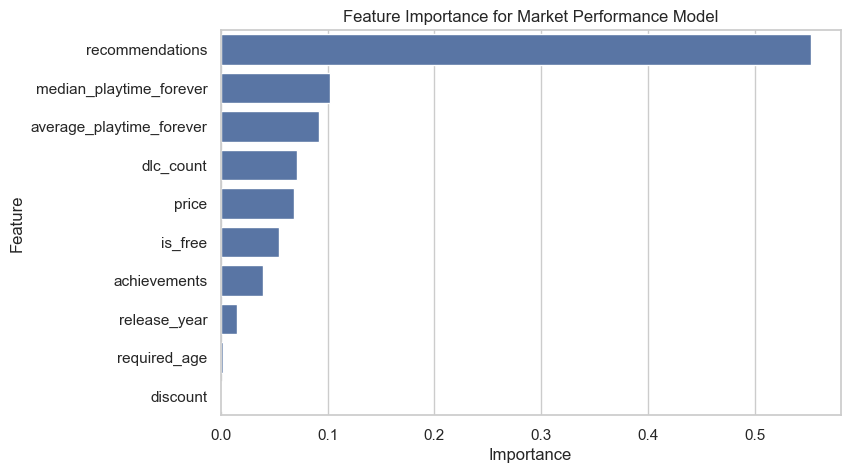

In [36]:
plt.figure(figsize=(8, 5))
sns.barplot(data=feature_importance, x='importance', y='feature')
plt.title('Feature Importance for Market Performance Model')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

### Model B: Product-level Feature Model

此模型排除 `recommendations`、平均遊玩時間與中位遊玩時間，避免把發售後市場表現直接拿來預測成功。

In [37]:
features_pre_release = [
    'price',
    'required_age',
    'dlc_count',
    'achievements',
    'discount',
    'release_year',
    'is_free'
]

model_df_pre = df[features_pre_release + ['is_successful']].dropna()

X = model_df_pre[features_pre_release]
y = model_df_pre['is_successful']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

rf_pre = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced',
    max_depth=8
)

rf_pre.fit(X_train, y_train)

y_pred = rf_pre.predict(X_test)
y_prob = rf_pre.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

       False       0.98      0.82      0.89     17038
        True       0.17      0.73      0.28       886

    accuracy                           0.81     17924
   macro avg       0.58      0.78      0.59     17924
weighted avg       0.94      0.81      0.86     17924

[[13952  3086]
 [  236   650]]
ROC AUC: 0.8524148782286415


In [38]:
feature_importance_pre = pd.DataFrame({
    'feature': features_pre_release,
    'importance': rf_pre.feature_importances_
}).sort_values('importance', ascending=False)

feature_importance_pre

,feature,importance
2,dlc_count,0.312854
0,price,0.241706
3,achievements,0.237476
5,release_year,0.128048
1,required_age,0.029937
6,is_free,0.026119
4,discount,0.023862


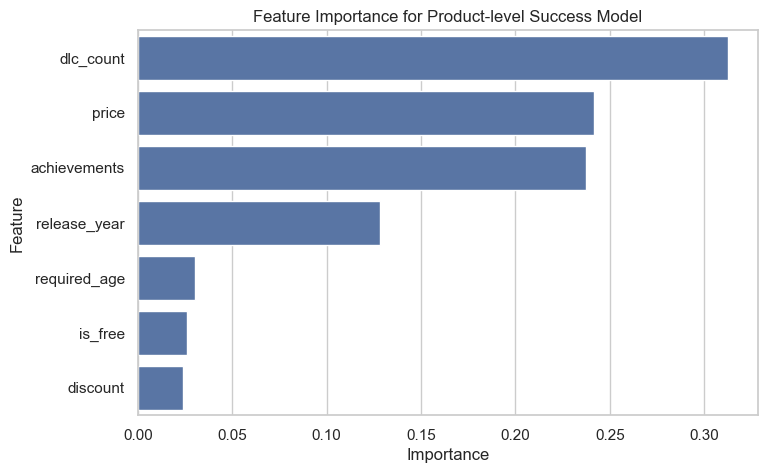

In [39]:
plt.figure(figsize=(8, 5))
sns.barplot(data=feature_importance_pre, x='importance', y='feature')
plt.title('Feature Importance for Product-level Success Model')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

市場表現模型 ROC AUC 約 0.985，但包含發售後變數，因此主要用於解釋成功遊戲的共同表現。產品層級模型 ROC AUC 約 0.852，雖然因成功遊戲比例低而 precision 較低，但能抓到多數成功遊戲，適合作為初步篩選模型。主要特徵包含 DLC 數量、價格、成就數與發行年份。

## 11. Key Findings and Business Recommendations

### Key Findings

1. 成功遊戲很稀少：只有約 4.94% 的 Steam 遊戲同時達到 80% 好評率與 1,000 則評論。
2. 中高價位與成功率較相關：20-40 美元區間成功率最高，但這是相關性，不代表提高價格就會成功。
3. 免費遊戲在完整資料中看似表現較好，但過濾低評論數遊戲後，付費遊戲成功率與好評率略高。
4. 成功 Tag 不只是熱門類型，而更偏向 Cult Classic、Moddable、Great Soundtrack、Remake、Classic、Nostalgia 等具備社群與情感價值的標籤。
5. 獨立遊戲存活不容易，只有約 7.98% 達到存活門檻；具備可重玩性、社群延伸、合作遊玩或明確利基定位的獨立遊戲存活率較高。
6. 產品層級特徵能提供一定預測力，Random Forest 模型在不使用評論與玩家行為欄位時仍達到約 0.852 ROC AUC。

### Business Recommendations

1. 開發者不應只依賴低價策略；如果內容深度與品質足夠，中高價位可能更符合成功遊戲特徵。
2. 獨立遊戲應優先思考可重玩性、社群擴充與明確受眾定位，例如 Moddable、Co-op、Sandbox、Colony Sim、Roguelike Deckbuilder 等方向。
3. 行銷與產品分析時應同時看好評率與評論數，避免高好評但低樣本的遊戲誤導判斷。
4. 發行月份可作為輔助參考，但市場飽和、曝光競爭與遊戲本身定位更可能影響成功機率。

### Limitations

- 資料沒有真實銷售額，因此使用評論數、好評率與同時在線人數作為市場表現替代指標。
- 2025 年資料只到 3 月，不能與完整年度直接比較。
- 部分欄位如 DLC 數量、折扣可能會隨時間改變。
- 本分析呈現相關性，不直接推論因果關係。